# Kafka Consumer

In [2]:
from kafka import KafkaConsumer
import json

# Create Kafka consumer
consumer = KafkaConsumer(
    "cancer_predictions",                
    bootstrap_servers="localhost:9092",  
    auto_offset_reset="earliest",        
    enable_auto_commit=True,        
    group_id="cancer_prediction_group",  
    value_deserializer=lambda x: json.loads(x.decode('utf-8'))  
)


Listening for predictions...

== New Prediction Received ==
Timestamp: 2025-05-03T19:40:55.320647

Patient Information:
  Age: Female
  BMI: 22
  Alcohol/Day: Non-Hispanic Asian
  Gender: 21.4
  Race: Yes
  Smokes?: 3
  Congestive Heart Failure: Yes
  Coronary Heart Disease: Yes
  Heart Attack: Yes
  Stroke: Yes
  Thyroid: Yes

Tabular Prediction: 0.0 (Confidence: 0.46)
Image Prediction: 0 (Confidence: 1.00)




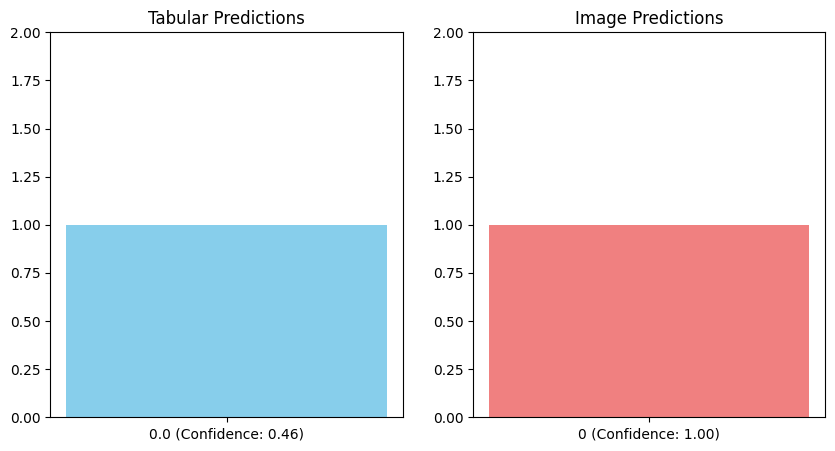

== New Prediction Received ==
Timestamp: 2025-05-03T19:41:43.202439

Patient Information:
  Age: Male
  BMI: 49
  Alcohol/Day: Non-Hispanic White
  Gender: 14.7
  Race: No
  Smokes?: 5.8
  Congestive Heart Failure: No
  Coronary Heart Disease: No
  Heart Attack: Yes
  Stroke: Yes
  Thyroid: Yes

Tabular Prediction: 0.0 (Confidence: 0.50)
Image Prediction: 0 (Confidence: 1.00)




KeyboardInterrupt: 

In [8]:
import matplotlib.pyplot as plt
from collections import Counter
import os

# Initialize counters
tabular_counter = Counter()
image_counter = Counter()
total_patients = 0

print("Listening for predictions...\n")

# Continuously listen to incoming messages
for message in consumer:
    data = message.value

    print("== New Prediction Received ==")

    # Timestamp
    timestamp = data.get("timestamp", "N/A")
    print(f"Timestamp: {timestamp}\n")
    
    # Extract predictions
    image_prediction = data.get("Image Prediction", "N/A")
    tabular_prediction = data.get("Tabular Prediction", "N/A")

    # Extract patient info
    patient_info = {k: v for k, v in data.items() if k not in ["timestamp", "Image Prediction", "Tabular Prediction"]}

    print("Patient Information:")
    for key, value in patient_info.items():
        print(f"  {key}: {value}")

    print(f"\nTabular Prediction: {tabular_prediction}")
    print(f"Image Prediction: {image_prediction}")

    print("\n" + "="*40 + "\n")

    # Update counters
    total_patients += 1
    tabular_counter[tabular_prediction] += 1
    image_counter[image_prediction] += 1



## Spark Dataframe

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import from_json, col
from pyspark.sql.types import *

# Start Spark session
spark = SparkSession.builder \
    .appName("CancerPredictionConsumer") \
    .config("spark.jars.packages", "org.apache.spark:spark-sql-kafka-0-10_2.13:3.5.4")\
    .getOrCreate()

:: loading settings :: url = jar:file:/home/hadoop/spark-3.5.4/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/jj/.ivy2/cache
The jars for the packages stored in: /home/jj/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-6d224a44-4a0f-43a2-b82b-486062dd856d;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.13;3.5.4 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.13;3.5.4 in central
	found org.apache.kafka#kafka-clients;3.4.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.10.5 in central
	found org.slf4j#slf4j-api;2.0.7 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.4 in central
	found org.apache.hadoop#hadoop-client-api;3.3.4 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.scala-lang.modules#scala-parallel-collections_2.13;1.0.4 in central
	found org.apache.commons#commons-pool2;2.11.1 in

In [2]:
schema = StructType([
    StructField("timestamp", StringType()),
    StructField("Age", DoubleType()),
    StructField("BMI", DoubleType()),
    StructField("Alcohol/Day", DoubleType()),
    StructField("Gender", StringType()),
    StructField("Smokes?", StringType()),
    StructField("Congestive Heart Failure", StringType()),
    StructField("Coronary Heart Disease", StringType()),
    StructField("Heart Attack", StringType()),
    StructField("Stroke", StringType()),
    StructField("Thyroid", StringType()),
    StructField("Race", StringType()),
    StructField("Image Prediction", StringType()),
    StructField("Tabular Prediction", StringType())
])

In [3]:
df = spark.readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", "localhost:9092") \
    .option("subscribe", "cancer_predictions") \
    .load()

In [4]:
from pyspark.sql.functions import col, from_json
from pyspark.sql.types import StructType, StringType

# Define schema (simplified for this case)
schema = StructType() \
    .add("timestamp", StringType()) \
    .add("Image Prediction", StringType()) \
    .add("Tabular Prediction", StringType())

json_df = df.selectExpr("CAST(value AS STRING) as json_value") \
    .select(from_json(col("json_value"), schema).alias("data")) \
    .select("data.*")


In [5]:
from pyspark.sql.functions import expr
from pyspark.sql.functions import substring


json_df = json_df.withColumn("TabularPredictionFirstChar", substring(col("Tabular Prediction"), 1, 1))
counts = json_df.groupBy("TabularPredictionFirstChar").count()

# Create temporary view
query = counts.writeStream \
    .format("memory") \
    .queryName("cancerCount") \
    .outputMode("complete") \
    .start()

25/05/03 20:37:48 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-aec8c692-a393-459a-93a5-38ad24b29546. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
25/05/03 20:37:48 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
25/05/03 20:37:51 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


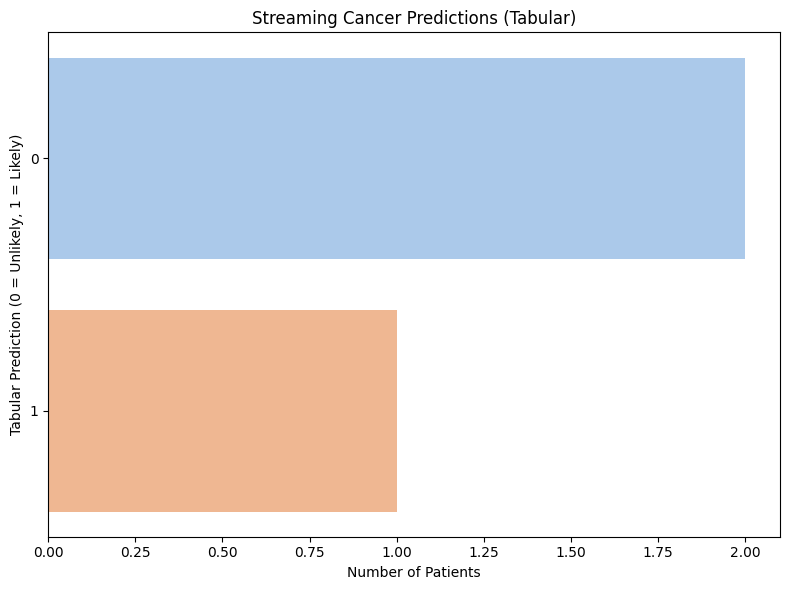

KeyboardInterrupt: 

In [7]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output

# Live plotting loop
while True:
    time.sleep(5)

    df = spark.sql("SELECT * FROM cancerCount").toPandas()

    clear_output(wait=True)
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.barplot(data=df, x='count', y='TabularPredictionFirstChar', hue='TabularPredictionFirstChar', palette='pastel')
    
    plt.xlabel("Number of Patients")
    plt.ylabel("Tabular Prediction (0 = Unlikely, 1 = Likely)")
    plt.title("Streaming Cancer Predictions (Tabular)")
    plt.tight_layout()
    plt.show()

